In [41]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
import plotly.express as px
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from bokeh.plotting import figure, show, output_file,output_notebook
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, RangeTool, Select, CustomJS, BoxAnnotation
from bokeh.io import output_file

In [2]:
df = pd.read_excel('نمونه 2 دیتاست برای تمرین های کلاس.xlsx')
df

c:\python\Sina\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2015-110422,2015-01-21,2015-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [4]:
df_1 = df[['Order Date','Quantity']]
df_1

,Order Date,Quantity
0,2017-11-08,2
1,2017-11-08,3
2,2017-06-12,2
3,2016-10-11,5
4,2016-10-11,2
...,...,...
9989,2015-01-21,3
9990,2018-02-26,2
9991,2018-02-26,2
9992,2018-02-26,4


In [5]:
df_2 = df_1.copy()
df_2['Sales'] = df['Sales']
df_2.set_index('Order Date',inplace=True)
df_2

,Quantity,Sales
Order Date,,
2017-11-08,2,261.9600
2017-11-08,3,731.9400
2017-06-12,2,14.6200
2016-10-11,5,957.5775
2016-10-11,2,22.3680
...,...,...
2015-01-21,3,25.2480
2018-02-26,2,91.9600
2018-02-26,2,258.5760


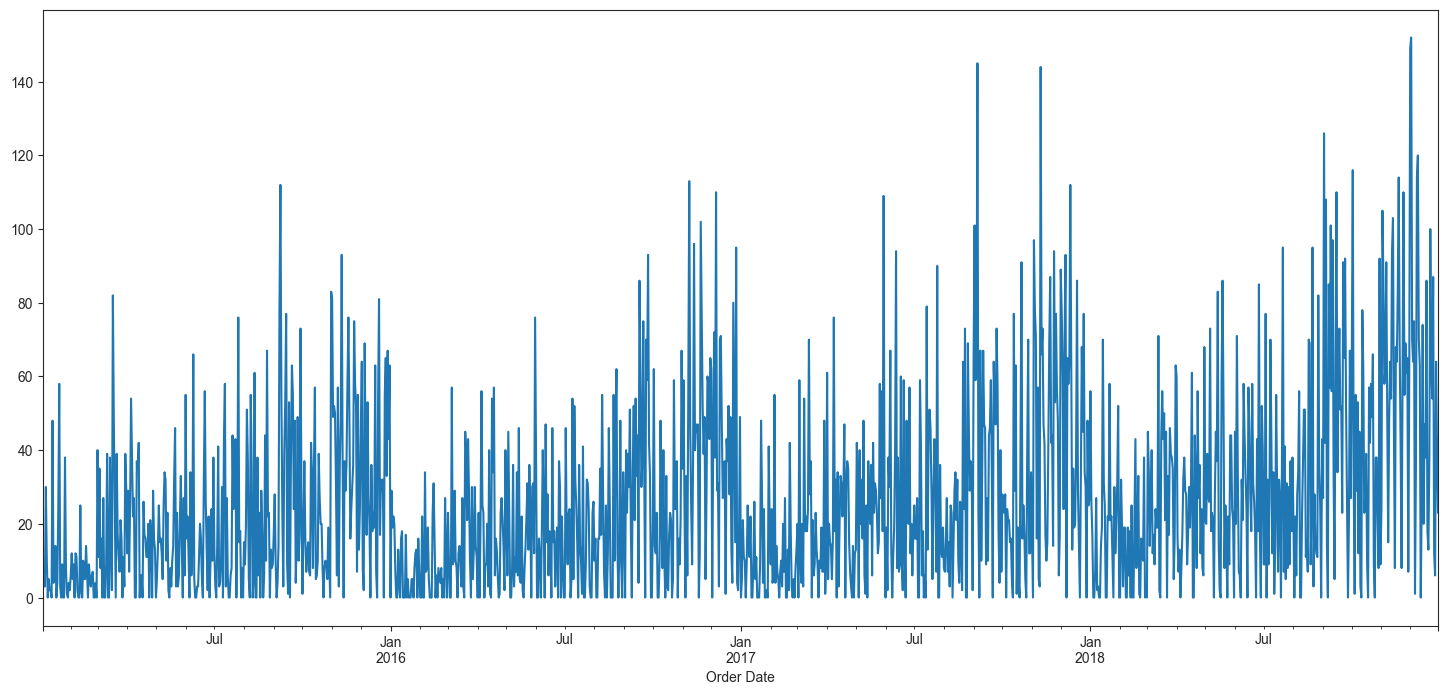

In [6]:
daily = df_2['Quantity'].resample('D').sum()
daily.plot(figsize=(18,8))
plt.show()

In [7]:
df_1 = df_1.copy()

df_1["Month"] = df_1["Order Date"].dt.month
df_1['Year'] = df_1['Order Date'].dt.year
df_1

,Order Date,Quantity,Month,Year
0,2017-11-08,2,11,2017
1,2017-11-08,3,11,2017
2,2017-06-12,2,6,2017
3,2016-10-11,5,10,2016
4,2016-10-11,2,10,2016
...,...,...,...,...
9989,2015-01-21,3,1,2015
9990,2018-02-26,2,2,2018
9991,2018-02-26,2,2,2018
9992,2018-02-26,4,2,2018


In [8]:
df_Time = df_2['Quantity'].resample('D').sum()

fig = px.line(
    df_Time,
    x=df_Time.index,
    y='Quantity',
    title='Daily Quantity'
)

fig.update_traces(
    line=dict(color="#499841", width=1.2),
    opacity=0.6
)

fig.update_layout(
    width=1800,
    height=800,
    template="simple_white"
)

fig.show()


In [9]:
df_1_per_Month = df_1.groupby(['Year','Month'])['Quantity'].sum().reset_index()

df_1_per_Month

,Year,Month,Quantity
0,2015,1,284
1,2015,2,159
2,2015,3,585
3,2015,4,536
4,2015,5,466
5,2015,6,521
6,2015,7,550
7,2015,8,609
8,2015,9,1000
9,2015,10,573


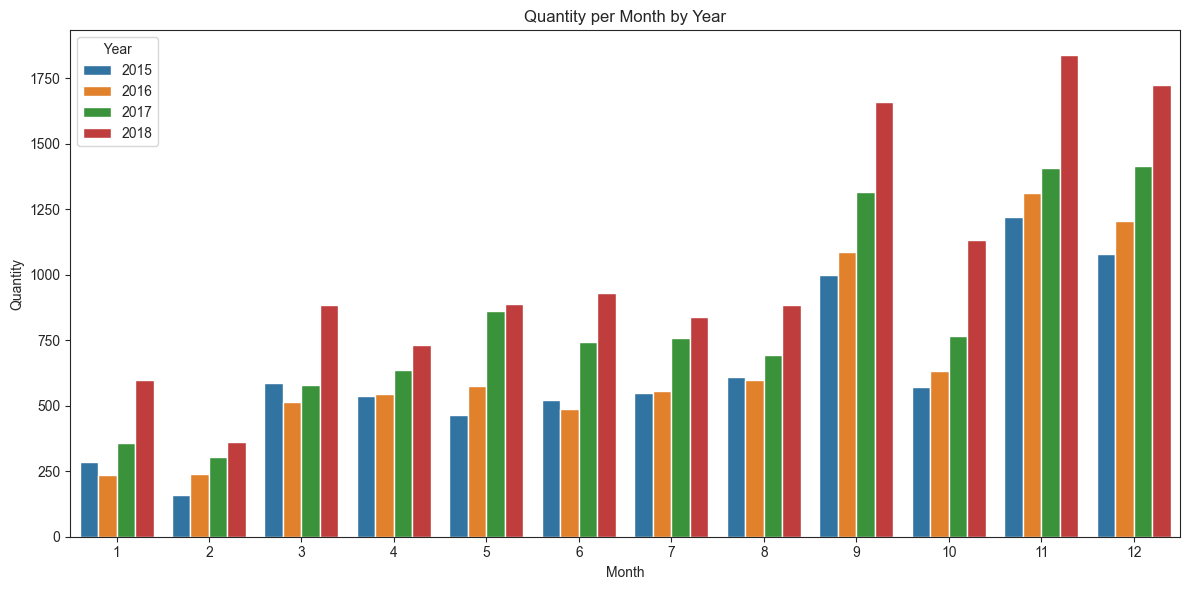

In [10]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_1_per_Month,
    x="Month",
    y="Quantity",
    hue="Year",
    palette="tab10",   
    errorbar=None      
)

plt.title("Quantity per Month by Year")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.legend(title=" Year ")
plt.tight_layout()
plt.show()

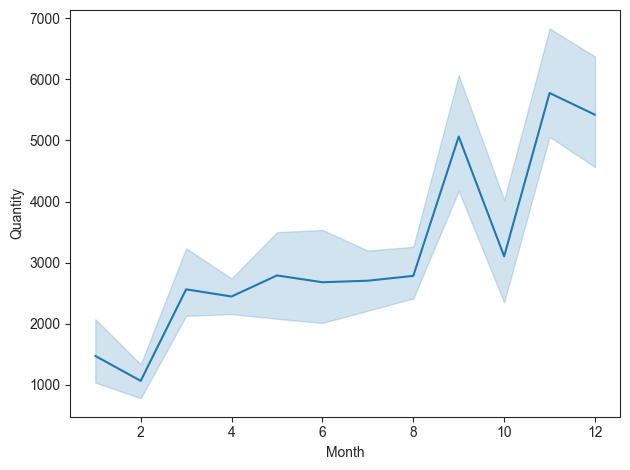

In [11]:
sns.lineplot(data=df_1_per_Month,x='Month',y='Quantity', estimator="sum", errorbar=('ci', 95))
plt.tight_layout()
plt.show()

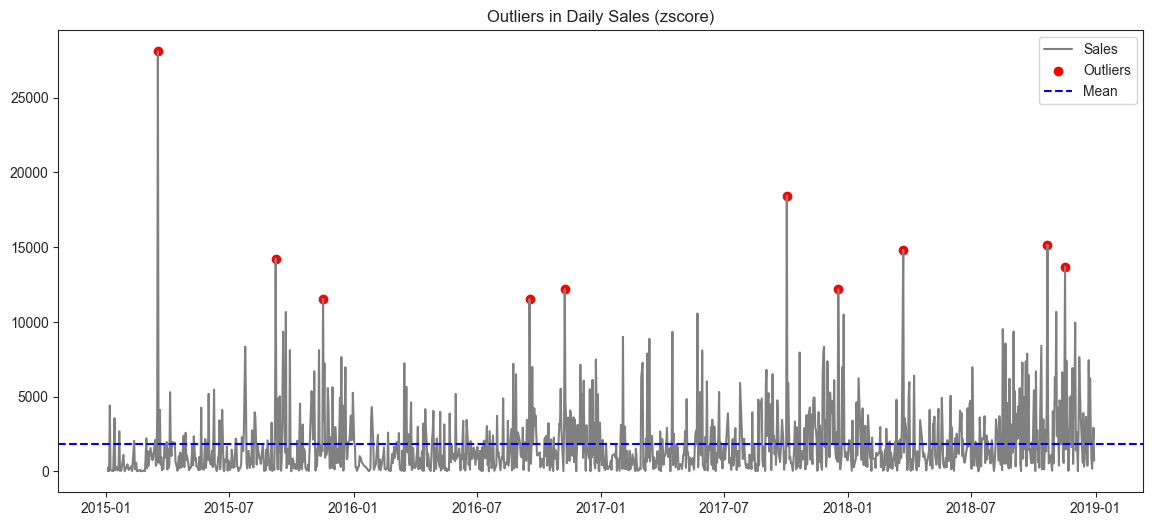

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

daily = df.groupby('Order Date')['Sales'].sum().reset_index()

mean_sales = daily['Sales'].mean()
std_sales = daily['Sales'].std()

daily['zscore'] = (daily['Sales'] - mean_sales) / std_sales
daily['zscore_abs'] = abs(daily['zscore'])

outliers_high = daily.nlargest(10, 'zscore_abs')

plt.figure(figsize=(14,6))
plt.plot(daily['Order Date'], daily['Sales'], label='Sales', color='gray')
plt.scatter(outliers_high['Order Date'], outliers_high['Sales'], color='red', label='Outliers')
plt.axhline(y=mean_sales, color='blue', linestyle='--', label='Mean')  
plt.title('Outliers in Daily Sales (zscore)')
plt.legend()
plt.show()

C:\Users\Sina\AppData\Local\Temp\ipykernel_28580\4267192988.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_series = daily_series.asfreq('H')  # هر ساعت یک رکورد (NaN برای ساعات جدید)
C:\Users\Sina\AppData\Local\Temp\ipykernel_28580\4267192988.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = daily_series.resample('M').mean()


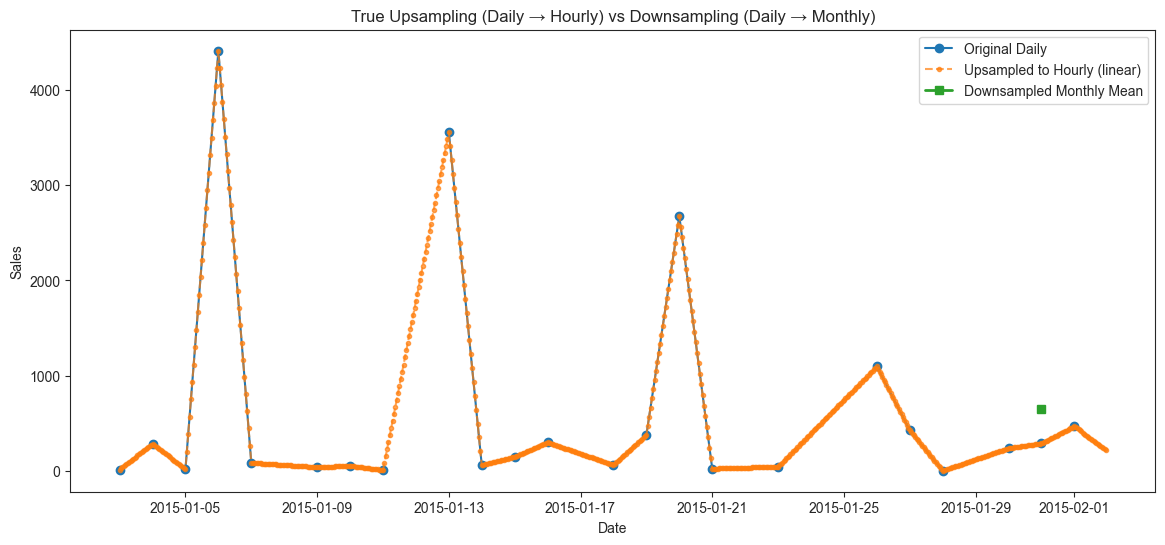

In [ ]:
daily_sales = df.groupby('Order Date')['Sales'].sum()
daily_series = daily_sales.asfreq('D')  

hourly_series = daily_series.asfreq('H')  
hourly_interp = hourly_series.interpolate(method='linear')  

monthly_mean = daily_series.resample('M').mean()

start_date = '2015-01-01'
end_date = '2015-02-01'

plt.figure(figsize=(14,6))
plt.plot(daily_series[start_date:end_date], 'o-', label='Original Daily', markersize=6)
plt.plot(hourly_interp[start_date:end_date], '.--', label='Upsampled to Hourly (linear)', alpha=0.7)
plt.plot(monthly_mean[start_date:end_date], 's-', label='Downsampled Monthly Mean', linewidth=2)
plt.legend()
plt.title('True Upsampling (Daily → Hourly) vs Downsampling (Daily → Monthly)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

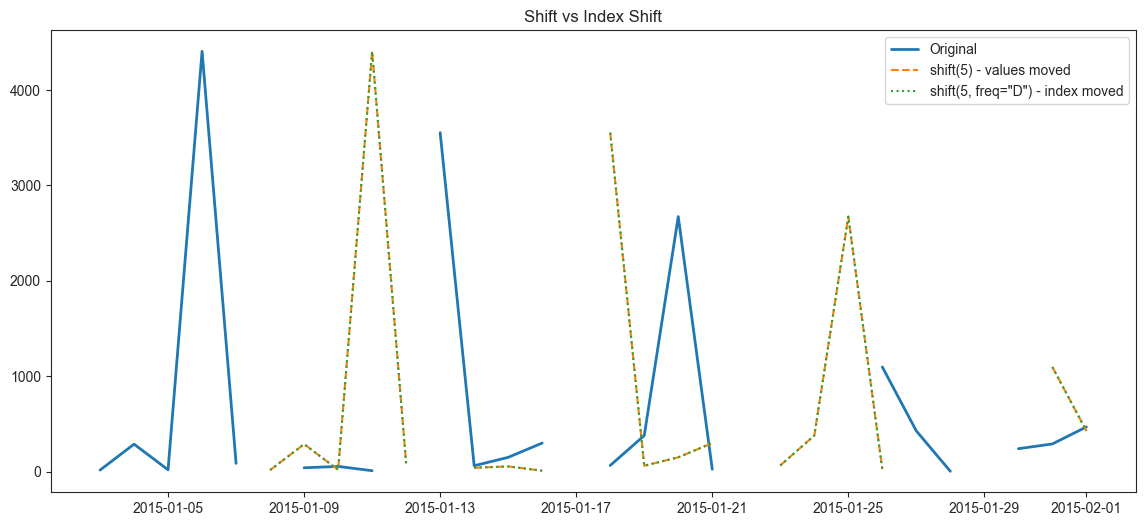

In [31]:
ts = daily_series.copy()
shifted_vals = ts.shift(5)
tshift_idx = ts.shift(5, freq='D')
plt.figure(figsize=(14,6))
plt.plot(ts[start_date:end_date], label='Original', linewidth=2)
plt.plot(shifted_vals[start_date:end_date], label='shift(5) - values moved', linestyle='--')
plt.plot(tshift_idx[start_date:end_date], label='shift(5, freq="D") - index moved', linestyle=':')
plt.legend()
plt.title('Shift vs Index Shift')
plt.show()

C:\Users\Sina\AppData\Local\Temp\ipykernel_28580\559277929.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily.resample('M', on='Order Date')['Sales'].sum()


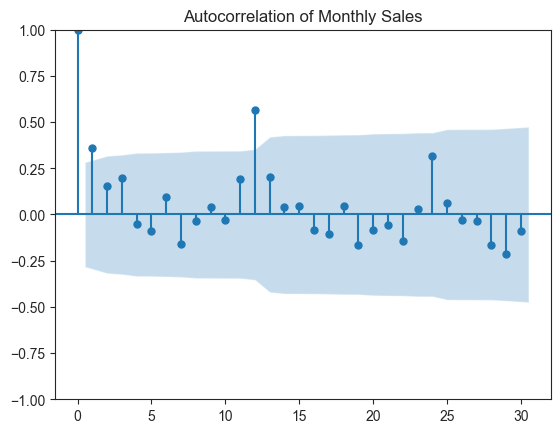

In [ ]:
monthly_sales = daily.resample('M', on='Order Date')['Sales'].sum()
plot_acf(monthly_sales, lags=30)
plt.title('Autocorrelation of Monthly Sales')
plt.show()

In [40]:
output_notebook()

data = daily_sales.loc['2015-01-01':'2015-03-31']

p = figure(x_axis_type='datetime', title='Daily Sales with Anomaly Box')
p.line(data.index, data, line_color='grey', line_width=2)
p.scatter(data.index, data, color='grey', size=4)

high_box = BoxAnnotation(top=3000, fill_alpha=0.2, fill_color='red', line_color='red')
p.add_layout(high_box)

show(p)

Loading BokehJS ...

In [ ]:

output_notebook()

df_d = pd.read_excel("نمونه 2 دیتاست برای تمرین های کلاس.xlsx")
df_d["Order Date"] = pd.to_datetime(df_d["Order Date"])

daily = df_d.groupby("Order Date")["Sales"].sum().reset_index()
source = ColumnDataSource(daily)

p = figure(height=300, width=900, x_axis_type="datetime",
           title="Daily Sales Time Series", tools="xpan", active_drag="xpan")
p.line("Order Date", "Sales", source=source, color="navy")
p.yaxis.axis_label = "Sales"

select = figure(height=130, width=900, y_range=p.y_range,
                x_axis_type="datetime", tools="", toolbar_location=None)
select.line("Order Date", "Sales", source=source, color="navy")

range_tool = RangeTool(x_range=p.x_range)
range_tool.overlay.fill_color = "green"
range_tool.overlay.fill_alpha = 0.3
select.add_tools(range_tool)

show(column(p, select))

Loading BokehJS ...

c:\python\Sina\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [15]:
# ------------------- 1. خواندن فایل اکسل -------------------
file_path = "نمونه 2 دیتاست برای تمرین های کلاس.xlsx"
df = pd.read_excel(file_path)
df["Order Date"] = pd.to_datetime(df["Order Date"])
output_notebook()

# ------------------- 2. تجمیع در سه سطح -------------------
# سطح روزانه
daily = df.groupby("Order Date")["Sales"].sum().reset_index()
daily = daily.rename(columns={"Order Date": "Date", "Sales": "Sales"})

# سطح ماهانه (ابتدا سال-ماه بسازیم)
df["YearMonth"] = df["Order Date"].dt.to_period("M")
monthly = df.groupby("YearMonth")["Sales"].sum().reset_index()
monthly["Date"] = monthly["YearMonth"].dt.start_time
monthly = monthly[["Date", "Sales"]]

# سطح سالانه
df["Year"] = df["Order Date"].dt.year
yearly = df.groupby("Year")["Sales"].sum().reset_index()
yearly["Date"] = pd.to_datetime(yearly["Year"], format="%Y")
yearly = yearly[["Date", "Sales"]]

# ------------------- 3. ساخت سه منبع داده (ColumnDataSource) -------------------
source_daily = ColumnDataSource(daily)
source_monthly = ColumnDataSource(monthly)
source_yearly = ColumnDataSource(yearly)

# منبع اولیه (روزانه)
current_source = source_daily

# ------------------- 4. نمودار اصلی (جزئیات) -------------------
detail_plot = figure(
    height=400, width=900,
    x_axis_type="datetime",
    title="Daily Sales Time Series (use RangeTool to zoom)",
    tools="xpan,reset,wheel_zoom",
    active_drag="xpan"
)
line = detail_plot.line("Date", "Sales", source=current_source, color="navy", line_width=2)
detail_plot.yaxis.axis_label = "Sales"
detail_plot.xaxis.axis_label = "Date"

# ------------------- 5. نمودار پایین برای RangeTool -------------------
overview = figure(
    height=150, width=900,
    x_axis_type="datetime",
    y_range=detail_plot.y_range,
    tools="",
    toolbar_location=None
)
overview.line("Date", "Sales", source=current_source, color="navy", line_width=1, alpha=0.6)

range_tool = RangeTool(x_range=detail_plot.x_range)
range_tool.overlay.fill_color = "green"
range_tool.overlay.fill_alpha = 0.3
overview.add_tools(range_tool)

# ------------------- 6. منوی کشویی (Select) با CustomJS -------------------
select = Select(
    title="Aggregation Level:",
    value="day",
    options=["day", "month", "year"]
)

# کد جاوااسکریپت برای تعویض منبع داده
callback = CustomJS(args=dict(
    source_daily=source_daily,
    source_monthly=source_monthly,
    source_yearly=source_yearly,
    line=line,
    overview_line=overview.renderers[0]  # اولین خط در overview
), code="""
    var level = cb_obj.value;
    var new_source;
    if (level === 'day') {
        new_source = source_daily;
    } else if (level === 'month') {
        new_source = source_monthly;
    } else {
        new_source = source_yearly;
    }
    line.data_source = new_source;
    overview_line.data_source = new_source;
    // به‌روزرسانی محدوده y (اختیاری)
    line.data_source.change.emit();
""")

select.js_on_change("value", callback)

# ------------------- 7. ذخیره خروجی به فایل HTML و نمایش -------------------
output_file("daily_sales_interactive.html",)
layout = column(detail_plot, overview, row(select))
show(layout)

c:\python\Sina\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Loading BokehJS ...

In [ ]:
output_notebook()

file_path = "نمونه 2 دیتاست برای تمرین های کلاس.xlsx"
df = pd.read_excel(file_path)
df["Order Date"] = pd.to_datetime(df["Order Date"])

metrics = ["Sales", "Quantity"]   
# سطح روزانه
daily = df.groupby("Order Date")[metrics].sum().reset_index()
daily = daily.rename(columns={"Order Date": "Date"})

# سطح ماهانه
df["YearMonth"] = df["Order Date"].dt.to_period("M")
monthly = df.groupby("YearMonth")[metrics].sum().reset_index()
monthly["Date"] = monthly["YearMonth"].dt.start_time
monthly = monthly.drop("YearMonth", axis=1)

# سطح سالانه
df["Year"] = df["Order Date"].dt.year
yearly = df.groupby("Year")[metrics].sum().reset_index()
yearly["Date"] = pd.to_datetime(yearly["Year"], format="%Y")
yearly = yearly.drop("Year", axis=1)

source_daily = ColumnDataSource(daily)
source_monthly = ColumnDataSource(monthly)
source_yearly = ColumnDataSource(yearly)

current_source = source_daily
current_metric = "Sales"  
detail_plot = figure(
    height=400, width=900,
    x_axis_type="datetime",
    title="Daily Sales Time Series (use RangeTool to zoom)",
    tools="xpan,reset,wheel_zoom",
    active_drag="xpan"
)
line = detail_plot.line("Date", current_metric, source=current_source, color="navy", line_width=2)
detail_plot.yaxis.axis_label = "Sales"
detail_plot.xaxis.axis_label = "Date"

overview = figure(
    height=150, width=900,
    x_axis_type="datetime",
    y_range=detail_plot.y_range,
    tools="",
    toolbar_location=None
)
overview_line = overview.line("Date", current_metric, source=current_source,
                              color="navy", line_width=1, alpha=0.6)

range_tool = RangeTool(x_range=detail_plot.x_range)
range_tool.overlay.fill_color = "green"
range_tool.overlay.fill_alpha = 0.3
overview.add_tools(range_tool)

agg_select = Select(title="Aggregation Level:", value="day",
                    options=["day", "month", "year"])
metric_select = Select(title="Measure:", value="Sales",
                       options=metrics)   


callback = CustomJS(args=dict(
    source_daily=source_daily,
    source_monthly=source_monthly,
    source_yearly=source_yearly,
    line=line,
    overview_line=overview_line,
    y_axis=detail_plot.yaxis[0],          
    agg_select=agg_select,
    metric_select=metric_select
), code="""
    // سطح تجمیع انتخاب‌شده
    var agg = agg_select.value;
    // معیار انتخاب‌شده
    var metric = metric_select.value;

    // انتخاب منبع داده بر اساس سطح تجمیع
    var new_source;
    if (agg === 'day') {
        new_source = source_daily;
    } else if (agg === 'month') {
        new_source = source_monthly;
    } else {
        new_source = source_yearly;
    }
    line.data_source = new_source;
    overview_line.data_source = new_source;

    // تغییر فیلد محور عمودی (y) در هر دو خط
    line.glyph.y = { field: metric };
    overview_line.glyph.y = { field: metric };

    // به‌روزرسانی لیبل محور عمودی
    y_axis.axis_label = metric;

    // اعمال تغییرات
    line.data_source.change.emit();
    line.glyph.change.emit();
    overview_line.glyph.change.emit();
""")

agg_select.js_on_change("value", callback)
metric_select.js_on_change("value", callback)

layout = column(detail_plot, overview, row(agg_select, metric_select))
show(layout)

Loading BokehJS ...

c:\python\Sina\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
